# Exercises "Lecture 10: Exploratory Data Analysis and Visualisation"

In this session, we will compute statistics and visualizations on Wikipedia articles from 16 categories, namely: 

> Airports, Artists, Astronauts, Astronomical_objects, Building, City, Comics_characters, Companies, Foods, Monuments_and_memorials, Politicians, Sports_teams, Sportspeople, Transport, Universities_and_colleges, Written_communication.

Data: wkp directory containing .txt files         
Python libraries
- [os](https://docs.python.org/3.8/library/os.html), for listdir() to list files in a directory 
- [glob](https://docs.python.org/3/library/glob.html), for listing files in a directory whose names match certain patterns
- [re](https://docs.python.org/3.8/library/re.html), for regular expressions 
- pandas
- spacy (or Stanza)

In [87]:
# LOAD THE LIBRARIES
import os
import glob
import re
import pandas as pd
import spacy
import matplotlib.pyplot as plt

## Regexp and loading text files into a Pandas dataframe

**Exercise 1** 

* Get the list of file names in the **wkp/** directory
* Hint: You can use os.path.basename to help you
* Use a regexp together with the list of categories (given above: 'Airports', 'Artists'....) to split each file name  into 'id' and 'category'. For example: 

> File Name: 'Monteverde_Angel_Monuments_and_memorials'

is split into: 

> Id: 'Monteverde_Angel'

> Category: 'Monuments_and_memorials'

* store each processed filename in a list of lists. The list is of the form 
```[[File name, Id, Category], ...]```

In [45]:
ctgrs = ["Airports", "Artists", "Astronauts", "Astronomical_objects", "Building", "City", "Comics_characters", "Companies", "Foods", "Monuments_and_memorials", "Politicians", "Sports_teams", "Sportspeople", "Transport", "Universities_and_colleges", "Written_communication"]

In [12]:
# Get list of files in wkp directory
dir_path = './wkp/'
files = os.listdir(dir_path)

# Filter only files (exclude directories)
# file_names = [f.strip('.txt') for f in files if os.path.isfile(os.path.join(dir_path, f))]
file_names =[os.path.splitext(f)[0] for f in os.listdir(dir_path) if f.endswith(".txt")]

print(file_names)

['Aktieselskab_Companies', 'Al-Thawra_(Libya)_Written_communication', 'Alan_Kurdi_(ship)_Transport', 'Aita_Mari_Transport', 'Airspace_Transport', 'Gre-No-Li_Sportspeople', 'Leif_Elggren_Artists', 'Jim_Renacci_Sports_teams', 'Roman_cement_Building', 'Natural_burial_Monuments_and_memorials', 'Sapphire_Stagg_Comics_characters', 'Hnu╠Бs╠Мt╠Мa_City', 'Ajilimo╠Бjili_Foods', 'Anti-shock_body_Transport', 'Al_Jazeera_Podcasts_Companies', 'Carrozza_(sandwich)_Foods', 'Ulrich_Walter_Astronauts', 'NGC_2452_Astronomical_objects', 'NGC_5824_Astronomical_objects', 'Miguel_A╠Бngel_Marti╠Бn_Bordera_Artists', 'Khozh-Ahmed_Noukhayev_Politicians', 'Al_and_Ann_Stohlman_Artists', 'March_for_Jesus_City', 'Messier_85_Astronomical_objects', 'Lori_Lemaris_Comics_characters', 'Airway_beacon_Transport', 'Relocation_of_professional_sports_teams_in_Australia_and_New_Zealand_Sports_teams', 'John_Akii-Bua_Sportspeople', 'Cannonball_(Marvel_Comics)_Comics_characters', 'Wetted_area_Building', 'Al_Fazl_(newspaper)_Writt

In [ ]:
import re

def split_file_id(filename, categories):
    pattern = rf"^(.*)_({'|'.join(map(re.escape, categories))})$"
    match = re.match(pattern, filename)
    if match:
        return match.group(1), match.group(2)
    return None, None

# Example usage:
# categories = ["Building", "Aeroport", "Astronomical_objects"]
filename = "Moon_Astronomical_objects.txt"

file_id, category = split_file_id(filename, ctgrs)
print("ID:", file_id)
print("Category:", category)

ID: None
Category: None


In [10]:
file_names

['Aktieselskab_Companies',
 'Al-Thawra_(Libya)_Written_communication',
 'Alan_Kurdi_(ship)_Transpor',
 'Aita_Mari_Transpor',
 'Airspace_Transpor',
 'Gre-No-Li_Sportspeople',
 'Leif_Elggren_Artists',
 'Jim_Renacci_Sports_teams',
 'Roman_cement_Building',
 'Natural_burial_Monuments_and_memorials',
 'Sapphire_Stagg_Comics_characters',
 'Hnu╠Бs╠Мt╠Мa_City',
 'Ajilimo╠Бjili_Foods',
 'Anti-shock_body_Transpor',
 'Al_Jazeera_Podcasts_Companies',
 'Carrozza_(sandwich)_Foods',
 'Ulrich_Walter_Astronauts',
 'NGC_2452_Astronomical_objects',
 'NGC_5824_Astronomical_objects',
 'Miguel_A╠Бngel_Marti╠Бn_Bordera_Artists',
 'Khozh-Ahmed_Noukhayev_Politicians',
 'Al_and_Ann_Stohlman_Artists',
 'March_for_Jesus_City',
 'Messier_85_Astronomical_objects',
 'Lori_Lemaris_Comics_characters',
 'Airway_beacon_Transpor',
 'Relocation_of_professional_sports_teams_in_Australia_and_New_Zealand_Sports_teams',
 'John_Akii-Bua_Sportspeople',
 'Cannonball_(Marvel_Comics)_Comics_characters',
 'Wetted_area_Building',
 '

In [13]:
for filename in file_names:
    file_id, category = split_file_id(filename, ctgrs)
    print("ID:", file_id)
    print("Category:", category)

ID: Aktieselskab
Category: Companies
ID: Al-Thawra_(Libya)
Category: Written_communication
ID: Alan_Kurdi_(ship)
Category: Transport
ID: Aita_Mari
Category: Transport
ID: Airspace
Category: Transport
ID: Gre-No-Li
Category: Sportspeople
ID: Leif_Elggren
Category: Artists
ID: Jim_Renacci
Category: Sports_teams
ID: Roman_cement
Category: Building
ID: Natural_burial
Category: Monuments_and_memorials
ID: Sapphire_Stagg
Category: Comics_characters
ID: Hnu╠Бs╠Мt╠Мa
Category: City
ID: Ajilimo╠Бjili
Category: Foods
ID: Anti-shock_body
Category: Transport
ID: Al_Jazeera_Podcasts
Category: Companies
ID: Carrozza_(sandwich)
Category: Foods
ID: Ulrich_Walter
Category: Astronauts
ID: NGC_2452
Category: Astronomical_objects
ID: NGC_5824
Category: Astronomical_objects
ID: Miguel_A╠Бngel_Marti╠Бn_Bordera
Category: Artists
ID: Khozh-Ahmed_Noukhayev
Category: Politicians
ID: Al_and_Ann_Stohlman
Category: Artists
ID: March_for_Jesus
Category: City
ID: Messier_85
Category: Astronomical_objects
ID: Lori_Le

**Exercise 2** 
* Extract the content of the file (use **read()**, cf. python_basics cheatsheet))
* Create a list of lists of the form (id, category, file_content). Save it to a variable "data4pandas" e.g., 

```
data4pandas = [['Monteverde_Angel', 'Monuments_and_memorials', 'The Monteverde Angel or Angel of the Resurrect ....], ...]
```

In [19]:
# YOUR CODE HERE
data4pandas = []
for filename in os.listdir(dir_path):
        file_path = os.path.join(dir_path, filename)
        file_id, category = split_file_id(os.path.splitext(filename)[0], ctgrs)
        if os.path.isfile(file_path):  # Ensure it's a file
            with open(file_path, "r", encoding="utf-8") as file:
                data4pandas.append([file_id, category, file.read()])

**Exercise 3** 

* Create a dataframe from this list of lists (i.e. data4pandas). Remember to add the following column headers: 'id', 'category' and'text' (cf. pandas CS). Save this dataframe to a variable called 'df'. (it is a convention to name pandas dataframe starting with 'df')
* inspect for yourself the first 10 and last 10 rows 

In [21]:
# YOUR CODE HERE
columns = ["id", "category", "text"]
df = pd.DataFrame(data4pandas, columns=columns)

In [22]:
df.head()

,id,category,text
0,Aktieselskab,Companies,Aktieselskab (pronounced [ˈɑkɕəselˌskɛˀp]; abb...
1,Al-Thawra_(Libya),Written_communication,"Al-Thawra (Arabic: الثورة, 'The Revolution') w..."
2,Alan_Kurdi_(ship),Transport,"Alan Kurdi, named after the drowned Syrian chi..."
3,Aita_Mari,Transport,The Aita Mari is a ship of the Maydayterraneo ...
4,Airspace,Transport,Airspace is the portion of the atmosphere cont...


In [23]:
df.tail()

,id,category,text
155,Uran_Butka,Politicians,Uran Butka (2 December 1938) is an Albanian wr...
156,Akira_Toriyama_(ophthalmologist),Universities_and_colleges,"Akira Toriyama (鳥山 晃, Toriyama Akira, 20 June ..."
157,Stein_2051,Astronomical_objects,"Stein 2051 (Gliese 169.1, G 175-034, LHS 26/27..."
158,James_A._Abrahamson,Astronauts,"James Alan Abrahamson (born May 19, 1933) is a..."
159,Al-Quds_College,Universities_and_colleges,Al-Quds College in Jordan was established in 1...


## Extract the list of categories

**Exercise 4** 
    
- store the content of the **'category'** column into a string (cf. Pandas CS)
- extract the set of unique categories from that string (cf. python basic CS)   
You should find the following 16 categories

```
['Comics_characters', 'Astronauts', 'Transport', 'Artists', 'Written_communication', 'Sports_teams', 'Foods', 'Airports', 'Monuments_and_memorials', 'Politicians', 'Sportspeople', 'Building', 'Universities_and_colleges', 'Astronomical_objects', 'Companies', 'City']
```

In [26]:
# YOUR CODE HERE
set(df['category'].tolist())

{'Airports',
 'Artists',
 'Astronauts',
 'Astronomical_objects',
 'Building',
 'City',
 'Comics_characters',
 'Companies',
 'Foods',
 'Monuments_and_memorials',
 'Politicians',
 'Sports_teams',
 'Sportspeople',
 'Transport',
 'Universities_and_colleges',
 'Written_communication'}

## Extract the list of headers from the 'text' column

**Exercise 5** 

Hint: In the Wikipedia articles, headers are surrounded by "==" 

_*E.g., ==  Background == *_

- Define a function called 'get_title' which extracts headers from a text (Use a regular expression)
- Apply this function to the **'text'** column in your pandas data frame (use the pandas 'apply' method)
- Store the result (the list of headers associated with each text in the frame) into a new pandas serie called 'headers'
- Concatenate this series to your pandas dataframe

In [29]:
# YOUR CODE HERE
import re

def get_title(text):
    pattern = r"^==\s*(.*?)\s*==$"  # Matches '== Header ==' with optional spaces
    return re.findall(pattern, text, re.MULTILINE)

df['headers'] = df['text'].apply(get_title)


In [31]:
df

,id,category,text,headers
0,Aktieselskab,Companies,Aktieselskab (pronounced [ˈɑkɕəselˌskɛˀp]; abb...,"[Liability, Formation of an aktieselskab, Shar..."
1,Al-Thawra_(Libya),Written_communication,"Al-Thawra (Arabic: الثورة, 'The Revolution') w...",[References]
2,Alan_Kurdi_(ship),Transport,"Alan Kurdi, named after the drowned Syrian chi...","[Historical, Acquisition by the humanitarian o..."
3,Aita_Mari,Transport,The Aita Mari is a ship of the Maydayterraneo ...,"[Aita Mari documentary, See also, References]"
4,Airspace,Transport,Airspace is the portion of the atmosphere cont...,"[Horizontal boundary, Vertical boundary, Contr..."
...,...,...,...,...
155,Uran_Butka,Politicians,Uran Butka (2 December 1938) is an Albanian wr...,"[Life, Work, = Monographies and historical stu..."
156,Akira_Toriyama_(ophthalmologist),Universities_and_colleges,"Akira Toriyama (鳥山 晃, Toriyama Akira, 20 June ...","[Biography and medical career, Photography, Bo..."
157,Stein_2051,Astronomical_objects,"Stein 2051 (Gliese 169.1, G 175-034, LHS 26/27...","[Properties, References, External links]"
158,James_A._Abrahamson,Astronauts,"James Alan Abrahamson (born May 19, 1933) is a...","[Early life and education, Military career, = ..."


## Extracting the vocabulary of each category

For each category, we extract the corresponding vocabulary i.e., the list of tokens occurring in the corresponding texts (removing the duplicates)


Optional: for each category
- extract the list of headers
- extract the noun and verbs 

**Exercise 6**

* write a function called "remove_underscores" that takes a python string and replace all the '_' in it with a whitespace ' '. e.g. "This_is_a_text" becomes  "This is a text"
* write a function called "lowercase_string" that takes a python string and lowercases it. e.g. "This is a text" becomes  "this is a text"
* apply both of the remove_underscores and lowercase_string functions on the **'clean_text'** column of your dataframe. Save the output into a new column in your dataframe called 'clean_text' (consider using method chaining)

In [34]:
# YOUR CODE HERE
def remove_underscores(s):
    return s.replace('_', ' ')

def lowercase_string(s):
    return s.lower()

In [35]:
df['clean_text'] =df['text'].apply(remove_underscores)
df['clean_text'] =df['clean_text'].apply(lowercase_string)

In [36]:
df

,id,category,text,headers,clean_text
0,Aktieselskab,Companies,Aktieselskab (pronounced [ˈɑkɕəselˌskɛˀp]; abb...,"[Liability, Formation of an aktieselskab, Shar...",aktieselskab (pronounced [ˈɑkɕəselˌskɛˀp]; abb...
1,Al-Thawra_(Libya),Written_communication,"Al-Thawra (Arabic: الثورة, 'The Revolution') w...",[References],"al-thawra (arabic: الثورة, 'the revolution') w..."
2,Alan_Kurdi_(ship),Transport,"Alan Kurdi, named after the drowned Syrian chi...","[Historical, Acquisition by the humanitarian o...","alan kurdi, named after the drowned syrian chi..."
3,Aita_Mari,Transport,The Aita Mari is a ship of the Maydayterraneo ...,"[Aita Mari documentary, See also, References]",the aita mari is a ship of the maydayterraneo ...
4,Airspace,Transport,Airspace is the portion of the atmosphere cont...,"[Horizontal boundary, Vertical boundary, Contr...",airspace is the portion of the atmosphere cont...
...,...,...,...,...,...
155,Uran_Butka,Politicians,Uran Butka (2 December 1938) is an Albanian wr...,"[Life, Work, = Monographies and historical stu...",uran butka (2 december 1938) is an albanian wr...
156,Akira_Toriyama_(ophthalmologist),Universities_and_colleges,"Akira Toriyama (鳥山 晃, Toriyama Akira, 20 June ...","[Biography and medical career, Photography, Bo...","akira toriyama (鳥山 晃, toriyama akira, 20 june ..."
157,Stein_2051,Astronomical_objects,"Stein 2051 (Gliese 169.1, G 175-034, LHS 26/27...","[Properties, References, External links]","stein 2051 (gliese 169.1, g 175-034, lhs 26/27..."
158,James_A._Abrahamson,Astronauts,"James Alan Abrahamson (born May 19, 1933) is a...","[Early life and education, Military career, = ...","james alan abrahamson (born may 19, 1933) is a..."


**Exercise 7**

- Define a function 'get_tokens' which, given a category, return its vocabulary (the list of tokens occurring in the texts of that category and after removing the duplicates). One way to do this is to:
   - extract the category subframe i.e., all rows whose category column matches the input category
   - create a string out of the text column of that subframe (use str.cat(sep=" "), cf. Pandas CS)
   - run spacy or Stanza model on this string and extract the tokens from the resulting document (cf. Stanza or spacy CS)
   - use python set method to remove duplicate tokens
   - use python list method to convert the resulting set back into a list
- Create a new dataframe with headers **'CATEGORY'** and **'VOCABULARY'** in which you store for each category the corresponding vocabulary

In [32]:
from copy import deepcopy

In [37]:
nlp = spacy.load("en_core_web_sm")

In [41]:
# YOUR CODE HERE
def get_tokens(df, category):
    temp = deepcopy(df[df['category']==category])
    temp_s = ' '.join(temp['clean_text'])
    voc = list(set([token.text for token in nlp.tokenizer(temp_s)]))
    return voc

In [43]:
get_tokens(df, 'Transport')

['ways',
 'of',
 'proved',
 'interest',
 'defined',
 'state',
 'dimensions',
 'evolution',
 'asos',
 'akaflieg#akaflieg',
 'supersonic',
 'numerous',
 'nasa',
 'made',
 'should',
 'renamed',
 'house',
 'standpoint',
 'classes',
 'might',
 'akaflieg',
 'feet',
 'insufficient',
 'tv',
 'kilowatt',
 'noticed',
 'a&m',
 'julio',
 'available',
 'meant',
 'development',
 '·',
 'causing',
 '1933',
 'associated',
 'director',
 'attempts',
 'operations',
 '22.2',
 'cabinet',
 'fought',
 'parachute',
 'contact',
 'krebs',
 'grumman',
 'trsas',
 'penck',
 'typical',
 'wagner',
 'congestion',
 'training',
 'overall',
 'forerunner',
 'she',
 'suggestions',
 'state.for',
 'uncontrolled',
 'dissolution',
 'name',
 'contest',
 'glider',
 'able',
 'like',
 'in',
 'watch',
 '6',
 'maintenance',
 'died',
 'fliegergruppe',
 'recently',
 'knots',
 'sites',
 'widely',
 'bodies',
 'u',
 'braunschweig',
 'addition',
 'boeing',
 'carrots',
 'rotation',
 'issued',
 'alaska',
 'mall',
 'frankfurter',
 'envelope'

In [47]:
def get_voc_df(df, categories):
    voclist = []
    for c in categories:
        voc = get_tokens(df, c)
        voclist.append([c, voc])
    columns = ["CATEGORY", "VOCABULARY",]
    return pd.DataFrame(voclist, columns=columns)
            

df_voc = get_voc_df(df, ctgrs)

In [48]:
df_voc

,CATEGORY,VOCABULARY
0,Airports,"[express, of, seized, caa, bombing, interest, ..."
1,Artists,"[ways, express, of, pervasive, seized, erkläru..."
2,Astronauts,"[sts-122, of, proved, interest, defined, wilde..."
3,Astronomical_objects,"[ways, of, interest, reine, dimensions, verifi..."
4,Building,"[ways, of, proved, interest, defined, kozłowsk..."
5,City,"[igboland, of, ritually, mcintosh, interest, a..."
6,Comics_characters,"[weaknesses, express, coulson, of, themselves...."
7,Companies,"[express, of, seized, bombing, interest, alger..."
8,Foods,"[ways, of, sauce, hideki, ritually, approached..."
9,Monuments_and_memorials,"[express, of, ritually, valentin, interest, ca..."


## Visualising the differences in vocabulary size

**Exercise 8**

- Use pandas 'apply' method to compute the size of each category's vocabulary (the number of tokens)
- Add a **'VOCAB SIZE'** column to your the dataframe created in the previous exercise in which you input the size of the vocabulary for each category

In [ ]:
# YOUR CODE HERE

In [49]:
df_voc['VOCAB_SIZE'] = df_voc['VOCABULARY'].apply(len)

In [50]:
df_voc

,CATEGORY,VOCABULARY,VOCAB_SIZE
0,Airports,"[express, of, seized, caa, bombing, interest, ...",3340
1,Artists,"[ways, express, of, pervasive, seized, erkläru...",3249
2,Astronauts,"[sts-122, of, proved, interest, defined, wilde...",3571
3,Astronomical_objects,"[ways, of, interest, reine, dimensions, verifi...",1712
4,Building,"[ways, of, proved, interest, defined, kozłowsk...",2817
5,City,"[igboland, of, ritually, mcintosh, interest, a...",3282
6,Comics_characters,"[weaknesses, express, coulson, of, themselves....",4049
7,Companies,"[express, of, seized, bombing, interest, alger...",3024
8,Foods,"[ways, of, sauce, hideki, ritually, approached...",3401
9,Monuments_and_memorials,"[express, of, ritually, valentin, interest, ca...",3524


**Exercise 9**

Create a barplot showing the **VOCAB SIZE** of each **Category** (use e.g., pd.barh() method)

- the y axis should show the categories
- the x axis should show the vocabulary size

In [ ]:
# YOUR CODE HERE

<Axes: xlabel='CATEGORY'>

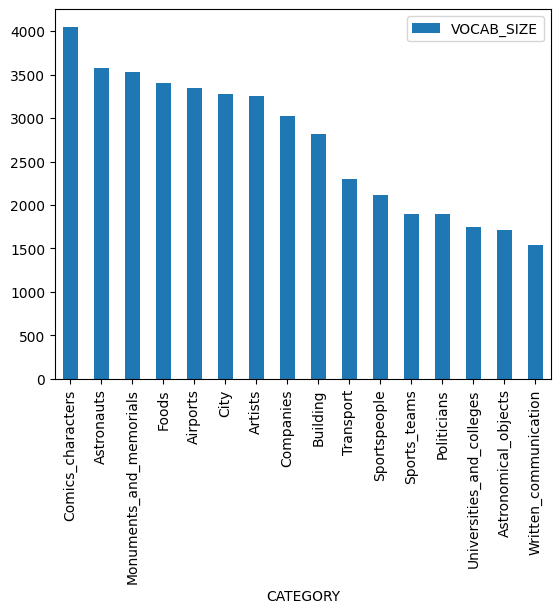

In [63]:
df_voc[['CATEGORY', 'VOCAB_SIZE']].sort_values(by=['VOCAB_SIZE'], ascending=False).plot.bar(x='CATEGORY',)

**Exercise 10**
* create a scatter plot showing the correlation between the number of headers and each category
* reminder: you have the headers stored in the pandas dataframe saved to the 'df' variable

In [71]:
df['headers_count'] = df['headers'].apply(len)

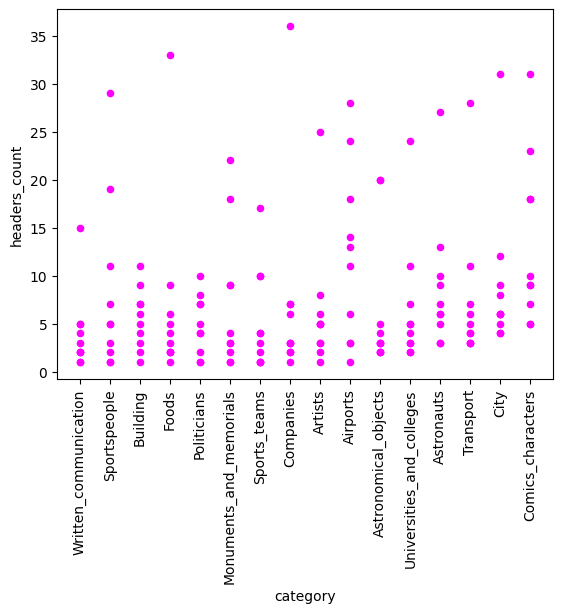

In [89]:
df.sort_values(by='headers_count').plot.scatter(x='category', y='headers_count', c='magenta',)
plt.xticks(rotation=90)
plt.show()

In [78]:
view = pd.DataFrame(df[['category', 'headers_count']].groupby('category').sum()).sort_values(by='headers_count', ascending=False)
view

,headers_count
category,
Comics_characters,135
Airports,121
City,91
Astronauts,89
Sportspeople,83
Transport,74
Monuments_and_memorials,72
Companies,70
Foods,67
